In [147]:
## set project root
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

assets_dir = os.path.join(project_root, "assets")

# Import Packages

We'll make use of the following packages:
- `numpy` is a package for scientific computing in python.
- `pandas` A powerful Python library for data manipulation and analysis.
- `seaborn` A data visualization library based on matplotlib.
- `scikit-learn` A comprehensive library for machine learning in Python.
- `kaggle` Using Kaggle API to download data.

In [158]:
import pandas as pd
import numpy as np
import seaborn as sns
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import logging
import importlib
import src.data_preprocessing
import src.eda
import src.save_results
importlib.reload(src.data_preprocessing)
importlib.reload(src.eda)
importlib.reload(src.save_results)
from src.data_preprocessing import DataPreprocessor
from src.eda import NumericalEDA, CategoricalEDA
from src.save_results import save_grid_search_results
from typing import List, Optional, Union
from scipy.stats import loguniform, uniform
from itertools import chain
import warnings
from io import StringIO

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error



# Download Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

print(os.listdir(path))

['used_cars.csv']


## Check data

In [4]:
## Check data
df = pd.read_csv(os.path.join(path, "used_cars.csv"))

# Data Preprocessing via pipeline

In [39]:
# Data Preprocessing via pipeline
dp = DataPreprocessor(df,assets_dir=assets_dir)
df_new = dp.preprocess()

COMPLETE: rename_column. -
 {'milage': 'mileage'}
No missing values found.
Data preprocessing completed successfully.


In [40]:
df_new.dtypes

brand                   object
model                   object
model_year               int64
mileage                float64
fuel_type               object
clean_title              int64
price                  float64
transmission_type       object
transmission_speeds    float64
hp                     float64
liters                 float64
cylinders              float64
ext_color_std           object
int_col_std             object
accident_reported        int64
dtype: object

In [41]:
df_new.head()

,brand,model,model_year,mileage,fuel_type,clean_title,price,transmission_type,transmission_speeds,hp,liters,cylinders,ext_color_std,int_col_std,accident_reported
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,1,10300.0,Automatic,6.0,300.0,3.7,6.0,black,black,1
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,1,38005.0,Automatic,8.0,291.0,3.8,6.0,blue,gray,1
2,Lexus,RX 350,2022,22372.0,Gasoline,0,54598.0,Automatic,8.0,295.0,3.5,6.0,blue,black,0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,1,15500.0,Automatic,7.0,354.0,3.5,6.0,black,black,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,0,34999.0,Automatic,8.0,228.0,2.0,4.0,white,black,0


In [37]:
df_new.shape

(4009, 17)

# Split Data

Setting columns to categorical dtype allows certain tree-based algorithms (like `XGBoost`, `LightGBM`, and `CatBoost`) to handle categorical features natively, resulting in more efficient and accurate modeling.

In [43]:
## Set categorical features
cat_cols = ['brand', 'model', 'fuel_type', 'clean_title','transmission_type','ext_color_std', 'int_col_std', 'accident_reported']
for col in cat_cols:
    df_new[col] = df_new[col].astype('category')


X = df_new.drop(columns=['price'])
y = df_new['price']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

# Sklearn trees/forests/GBM

## Grid Search for Tree Based Models

In [157]:
def make_preprocessor(X):
    col_cat = X.select_dtypes(include='category').columns.tolist()
    col_num = X.select_dtypes(include='number').columns.tolist()
    ohe = OneHotEncoder(
        handle_unknown='infrequent_if_exist',
        min_frequency=2,
        sparse_output=True,
        drop='if_binary'
    )
    return ColumnTransformer(
        [('cat', ohe, col_cat)],
        remainder='passthrough'
    )

def tree_based_modeling(X_train, y_train, cv=5):
    preprocessor = make_preprocessor(X_train)

    ## Set up pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor()) # Placeholder, will be replaced in GV
    ])

    ## Set up models and hyperparameter for GV
    param_grid = [
        {
            'model': [DecisionTreeRegressor(random_state=42)],
            'model__max_depth': [5, 10, 20],
            'model__min_samples_leaf': [5, 20, 50]
        },
        {
            'model': [RandomForestRegressor(random_state=42)],
            'model__n_estimators': [100, 200, 300],
            'model__min_samples_leaf': [5, 20, 50],
            'model__max_depth': [5, 10, 20],
            'model__max_features': ['sqrt', 'log2'],
            'model__min_samples_split': [5, 10]
        },
        {
            'model': [GradientBoostingRegressor(random_state=42)],
            'model__n_estimators': [100, 200, 300],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 10],
            'model__min_samples_leaf': [5, 20],
            'model__subsample': [0.6, 0.8, 1.0],
            'model__n_iter_no_change': [10],
            'model__validation_fraction': [0.1],
            'model__tol': [1e-4]
        },
    ]

    ## Grid Search
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Best parameters: ", grid.best_params_)
    print("Best RMSE: ", -grid.best_score_)

    return grid

In [159]:
warnings.filterwarnings("ignore", message=".*unknown categories.*")
warnings.filterwarnings("ignore", message=".*fits failed out of a total of.*")
warnings.filterwarnings("ignore", message=".*A worker stopped while some jobs were given to the executor.*")

grid_tree = save_grid_search_results(tree_based_modeling, X_train, y_train, X_test, y_test)

Starting training...
Best parameters:  {'model': GradientBoostingRegressor(random_state=42), 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200, 'model__n_iter_no_change': 10, 'model__subsample': 1.0, 'model__tol': 0.0001, 'model__validation_fraction': 0.1}
Best RMSE:  21426.317408621482
Training completed in 0:00:58.342476
Start model diagnostics...
Test RMSE: 126933.58
Test R²: 0.212
Saved best params for GradientBoostingRegressor to ../src/grid_results.csv
Saved best model as ../src/best_models/GradientBoostingRegressor_20251009_184515.joblib


### Model performance

In [119]:
## Check model performance
df_performance_tree = pd.DataFrame(grid_tree.cv_results_)

In [120]:
df_performance_tree.sort_values(by='mean_test_score', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features,param_model__n_estimators,param_model__learning_rate,...,param_model__validation_fraction,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
476,0.465536,0.275458,0.007020,0.001392,GradientBoostingRegressor(random_state=42),5,5,NaN,300.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-18747.193717,-21303.379499,-14946.337684,-25842.251237,-23136.351626,-20795.102752,3731.366602,1
470,0.475829,0.257417,0.007844,0.002706,GradientBoostingRegressor(random_state=42),5,5,NaN,200.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-18747.193717,-21303.379499,-14946.337684,-25842.251237,-23136.351626,-20795.102752,3731.366602,1
464,0.380132,0.111675,0.007255,0.001139,GradientBoostingRegressor(random_state=42),5,5,NaN,100.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-18677.214165,-21303.379499,-14946.337684,-25936.641067,-23136.351626,-20799.984808,3764.799955,3
457,0.433527,0.125461,0.007971,0.001344,GradientBoostingRegressor(random_state=42),5,1,NaN,300.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-18152.079976,-25097.829510,-16061.690070,-24636.642936,-21693.496328,-21128.347764,3547.210267,4
451,0.451331,0.131805,0.006398,0.000684,GradientBoostingRegressor(random_state=42),5,1,NaN,200.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-18152.079976,-25097.829510,-16061.690070,-24636.642936,-21693.496328,-21128.347764,3547.210267,4
461,0.228593,0.143865,0.005750,0.001602,GradientBoostingRegressor(random_state=42),5,5,NaN,100.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-19754.104818,-22184.327242,-14955.203801,-25936.641067,-23012.167932,-21168.488972,3681.623257,6
473,0.250973,0.161813,0.006681,0.001997,GradientBoostingRegressor(random_state=42),5,5,NaN,300.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-19754.104818,-22184.327242,-14955.203801,-25967.563625,-23012.167932,-21174.673484,3689.644995,7
467,0.258011,0.169692,0.007507,0.002580,GradientBoostingRegressor(random_state=42),5,5,NaN,200.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-19754.104818,-22184.327242,-14955.203801,-25967.563625,-23012.167932,-21174.673484,3689.644995,7
445,0.400330,0.089869,0.007521,0.003396,GradientBoostingRegressor(random_state=42),5,1,NaN,100.0,0.2,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-18398.704545,-25097.829510,-16061.690070,-24637.657302,-21719.052484,-21182.986782,3507.934321,9
314,0.557208,0.285684,0.009657,0.002559,GradientBoostingRegressor(random_state=42),5,5,NaN,300.0,0.1,...,0.1,{'model': GradientBoostingRegressor(random_sta...,-19215.520160,-22393.157638,-14472.732745,-25934.195970,-23905.631982,-21184.247699,4008.733599,10


### Visualize performance

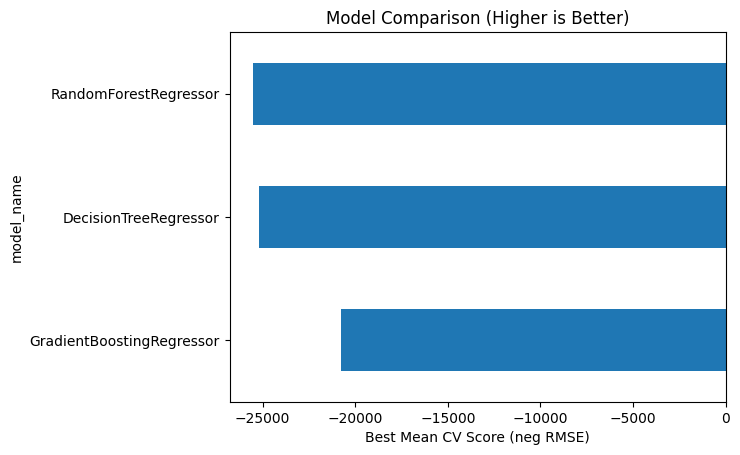

In [176]:
df_performance_tree['model_name'] = df_performance_tree['param_model'].apply(lambda x: type(x).__name__)

summary = df_performance_tree.groupby('model_name')['mean_test_score'].max().sort_values(ascending=False)
summary.plot(kind='barh')
plt.xlabel('Best Mean CV Score (neg RMSE)')
plt.title('Model Comparison (Higher is Better)')
plt.show()

> `GradientBoostingRegressor` achieved the best cross-validated performance on the training data (less negative RMSE means better performance).  
> In this context, a value closer to zero indicates a lower error, so shorter bars are better.

### Model Diagnostic

In [122]:
best_model_trees = grid_tree.best_estimator_

y_pred = best_model_trees.predict(X_test)

## Calculate metrics
rmse_tree = root_mean_squared_error(y_test, y_pred)
r2_tree = r2_score(y_test, y_pred)


print(f"RMSE: {rmse_tree:.2f}")
print(f"R²: {r2_tree:.3f}")


RMSE: 127794.41
R²: 0.201


> The best tree-based model outperformed the baseline linear regression model.  
> RMSE is lower and R² is higher compared to the baseline, indicating better predictive accuracy and fit.

# XGBoost

## Grid Search for XGBoost, LightGBM

In [135]:
print(best_model_trees['model'])

GradientBoostingRegressor(learning_rate=0.2, max_depth=5, min_samples_leaf=5,
                          n_estimators=200, n_iter_no_change=20,
                          random_state=42)


In [141]:
type(grid_tree.best_params_['model']).__name__

'GradientBoostingRegressor'

In [137]:
type(best_model_trees['model']).__name__

'GradientBoostingRegressor'

In [174]:
def xgboost_modeling(X_train, y_train, cv=5, n_iter=3000):
    pipeline = Pipeline([
        ('model', XGBRegressor())
    ])

    param_grid = [
        {
            'model': [XGBRegressor(objective='reg:squarederror', tree_method='hist', enable_categorical=True, random_state=42)],
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 6, 10],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__subsample': [0.6, 0.8, 1.0],
            'model__colsample_bytree': [0.6, 0.8, 1.0],
            'model__reg_alpha': [0, 0.1, 1],
            'model__reg_lambda': [1, 2, 5]
        },
        {
            'model': [LGBMRegressor(random_state=42, verbose=-1, force_col_wise=True)],
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 6, 10],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__subsample': [0.6, 0.8, 1.0],
            'model__colsample_bytree': [0.6, 0.8, 1.0],
            'model__reg_alpha': [0, 0.1, 1],
            'model__reg_lambda': [1, 2, 5],
            'model__min_child_samples': [5, 20, 50]
        }
    ]

    grid = RandomizedSearchCV(
        pipeline,
        param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    print("Best model:", grid.best_estimator_['model'])
    print("Best params:", grid.best_params_)
    print("Best RMSE:", -grid.best_score_)

    return grid

In [175]:
# warnings.filterwarnings("ignore", message=".*No further splits with positive gain.*")
warnings.filterwarnings('ignore')

grid_xgb = save_grid_search_results(xgboost_modeling, X_train, y_train, X_test, y_test)

Starting training...
Best model: LGBMRegressor(colsample_bytree=0.8, force_col_wise=True, learning_rate=0.2,
              max_depth=3, min_child_samples=5, n_estimators=300,
              random_state=42, reg_alpha=1, reg_lambda=2, subsample=0.8,
              verbose=-1)
Best params: {'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_samples': 5, 'model__max_depth': 3, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8, 'model': LGBMRegressor(force_col_wise=True, random_state=42, verbose=-1)}
Best RMSE: 19414.792593876577
Training completed in 1:50:35.136222
Start model diagnostics...
Test RMSE: 126305.00
Test R²: 0.220
Saved best params for LGBMRegressor to ../src/grid_results.csv
Saved best model as ../src/best_models/LGBMRegressor_20251009_192845.joblib


## Model performance

In [168]:
df_performance_xgb = pd.DataFrame(grid_xgb.cv_results_)
df_performance_xgb.sort_values(by='mean_test_score', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_lambda,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,...,param_model__min_child_samples,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
39,3.670262,0.241330,0.004307,0.000872,1.0,2,0.0,300,3,0.2,...,5.0,"{'model__subsample': 1.0, 'model__reg_lambda':...",-17285.910978,-22735.988060,-13922.761053,-24644.744692,-21332.500081,-19984.380973,3876.408984,1
19,6.708348,0.137445,0.003711,0.000385,0.8,1,0.1,100,10,0.1,...,5.0,"{'model__subsample': 0.8, 'model__reg_lambda':...",-16089.752022,-22562.871989,-13987.136615,-26502.515353,-21076.346266,-20043.724449,4504.321175,2
8,7.458251,0.171359,0.005181,0.001140,0.8,1,0.0,300,6,0.1,...,20.0,"{'model__subsample': 0.8, 'model__reg_lambda':...",-16950.226562,-21062.859506,-15603.033761,-25541.099544,-21077.106436,-20046.865162,3510.471797,3
30,2.680501,0.056489,0.006212,0.002693,0.6,2,0.0,200,3,0.1,...,5.0,"{'model__subsample': 0.6, 'model__reg_lambda':...",-17943.818627,-20932.302908,-14232.182464,-25905.288258,-21801.879802,-20163.094412,3907.710096,4
23,6.452381,0.276807,0.003968,0.000291,0.6,2,0.0,200,6,0.2,...,20.0,"{'model__subsample': 0.6, 'model__reg_lambda':...",-16424.304701,-21128.136998,-16837.626488,-25531.813388,-22013.558105,-20387.087936,3404.852021,5
13,3.709333,0.322259,0.003901,0.000815,0.8,5,0.1,300,3,0.2,...,20.0,"{'model__subsample': 0.8, 'model__reg_lambda':...",-17326.468276,-20936.056369,-16821.109386,-26110.033013,-21098.065865,-20458.346582,3335.181046,6
4,4.808368,1.763785,0.006489,0.001321,1.0,1,0.0,200,10,0.2,...,20.0,"{'model__subsample': 1.0, 'model__reg_lambda':...",-17213.042871,-21313.236019,-17170.244227,-26265.219297,-20892.185884,-20570.785660,3344.225583,7
12,14.837796,0.328212,0.004885,0.000378,0.6,2,0.0,300,6,0.2,...,5.0,"{'model__subsample': 0.6, 'model__reg_lambda':...",-16362.161156,-25169.733502,-15435.642474,-25389.449620,-21334.882160,-20738.373782,4216.526389,8
43,8.034678,0.425866,0.004280,0.000393,1.0,5,0.0,300,6,0.1,...,20.0,"{'model__subsample': 1.0, 'model__reg_lambda':...",-17303.723991,-23177.412798,-15882.371498,-25867.799290,-22455.745601,-20937.410636,3752.033645,9
28,5.369784,0.336483,0.003999,0.000401,1.0,1,0.1,200,6,0.1,...,20.0,"{'model__subsample': 1.0, 'model__reg_lambda':...",-17653.985228,-23271.224285,-15938.272438,-25797.917273,-22046.792204,-20941.638286,3635.219777,10


## Visualize performance

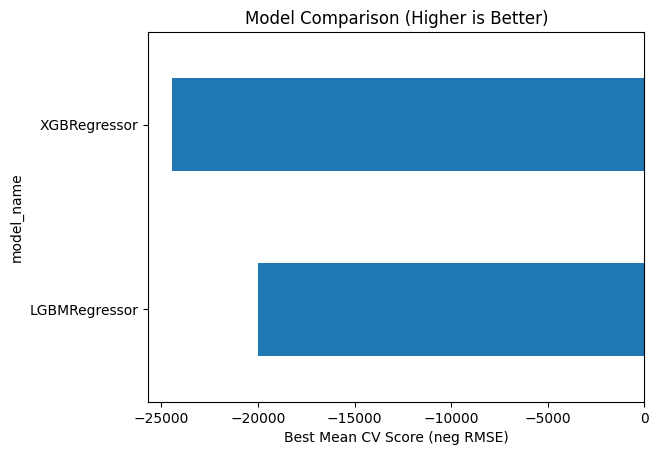

In [177]:
df_performance_xgb['model_name'] = df_performance_xgb['param_model'].apply(lambda x: type(x).__name__)

summary_xgb = df_performance_xgb.groupby('model_name')['mean_test_score'].max().sort_values(ascending=False)
summary_xgb.plot(kind='barh')
plt.xlabel('Best Mean CV Score (neg RMSE)')
plt.title('Model Comparison (Higher is Better)')
plt.show()

## Model Diagnostic

In [178]:
best_model_xgb = grid_xgb.best_estimator_

y_pred = best_model_xgb.predict(X_test)

## Calculate metrics
rmse_xgb = root_mean_squared_error(y_test, y_pred)
r2_xgb = r2_score(y_test, y_pred)


print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²: {r2_xgb:.3f}")


RMSE: 126305.00
R²: 0.220


# CatBoost

In [181]:
def catboost_modeling(X_train, y_train, cat_cols=cat_cols, cv=5):
    pipeline = Pipeline([
        ('model', CatBoostRegressor())
    ])

    param_grid = [
        {
            'model': [CatBoostRegressor(
                random_state=42, 
                thread_count=-1, 
                loss_function='RMSE',
                cat_features=cat_cols,
                verbose=0
                )],
            'model__iterations': [100, 200, 300],
            'model__depth': [3, 6, 10],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__l2_leaf_reg': [1, 3, 5],  # Important regularization param
            'model__border_count': [32, 64],
            'model__bagging_temperature': [0, 1],  
            'model__random_strength': [1, 2],  
        }
    ]

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    # grid.fit(X_train, y_train, **{'model__cat_features': cat_cols})
    grid.fit(X_train, y_train)
    print("Best model:", grid.best_estimator_['model'])
    print("Best params:", grid.best_params_)
    print("Best RMSE:", -grid.best_score_)

    return grid

In [182]:
grid_cat = save_grid_search_results(catboost_modeling, X_train, y_train, X_test, y_test)

Starting training...
Best model: <catboost.core.CatBoostRegressor object at 0x318badd00>
Best params: {'model': <catboost.core.CatBoostRegressor object at 0x330577920>, 'model__bagging_temperature': 0, 'model__border_count': 32, 'model__depth': 6, 'model__iterations': 300, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.2, 'model__random_strength': 2}
Best RMSE: 20159.004259751768
Training completed in 0:20:58.296173
Start model diagnostics...
Test RMSE: 129008.28
Test R²: 0.186
Saved best params for CatBoostRegressor to ../src/grid_results.csv
Saved best model as ../src/best_models/CatBoostRegressor_20251010_161045.joblib


## Model performance

In [183]:
df_performance_cat = pd.DataFrame(grid_cat.cv_results_)

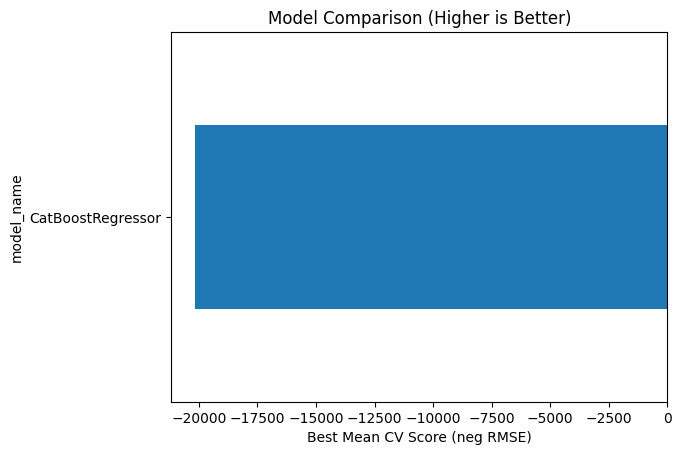

In [184]:
df_performance_cat['model_name'] = df_performance_cat['param_model'].apply(lambda x: type(x).__name__)

summary_cat = df_performance_cat.groupby('model_name')['mean_test_score'].max().sort_values(ascending=False)
summary_cat.plot(kind='barh')
plt.xlabel('Best Mean CV Score (neg RMSE)')
plt.title('Model Comparison (Higher is Better)')
plt.show()

## Model Diagnostic

In [185]:
best_model_cat = grid_cat.best_estimator_

y_pred = best_model_cat.predict(X_test)

## Calculate metrics
rmse_cat = root_mean_squared_error(y_test, y_pred)
r2_cat = r2_score(y_test, y_pred)


print(f"RMSE: {rmse_cat:.2f}")
print(f"R²: {r2_cat:.3f}")


RMSE: 129008.28
R²: 0.186


---
After trying different models, `LightGBM` model has the best performance - smallest RMSE and highest R^2